In [11]:
import pandas as pd
import numpy as np
import h3
import matplotlib.pyplot as plt

In [2]:
taxi_data_processed = pd.read_parquet(
    "../data/taxi_data_processed.parquet"
)

final_grid = pd.read_parquet(
    "../data/final_grid.parquet"
)

In [7]:
taxi_data_processed.info()

<class 'pandas.DataFrame'>
Index: 6012349 entries, 0 to 6041176
Data columns (total 17 columns):
 #   Column                Dtype         
---  ------                -----         
 0   Trip ID               str           
 1   Taxi ID               str           
 2   Trip Start Timestamp  str           
 3   Trip End Timestamp    str           
 4   Trip Seconds          float64       
 5   Trip Miles            float64       
 6   Pickup Census Tract   int64         
 7   Dropoff Census Tract  int64         
 8   Trip Total            float64       
 9   Company               str           
 10  h3_index_pickup       str           
 11  h3_index_dropoff      str           
 12  Pickup Hour           datetime64[us]
 13  Dropoff Hour          datetime64[us]
 14  weekday               str           
 15  hour                  int32         
 16  month                 int32         
dtypes: datetime64[us](2), float64(3), int32(2), int64(2), str(8)
memory usage: 2.3 GB


## temporal patterns

In [9]:
taxi_data_processed["date"] = taxi_data_processed["Pickup Hour"].dt.date

taxi_data_processed['month'] = taxi_data_processed['Pickup Hour'].dt.month

taxi_data_processed["hour"] = taxi_data_processed["Pickup Hour"].dt.hour

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

taxi_data_processed["weekday"] = pd.Categorical(
    taxi_data_processed["Pickup Hour"].dt.day_name(),
    categories=weekday_order,
    ordered=True
)

In [10]:
hourly_demand = taxi_data_processed.groupby("hour").size()

weekly_demand = taxi_data_processed.groupby("weekday").size()

hourly_duration_mean = taxi_data_processed.groupby("hour")["Trip Seconds"].mean()

hourly_demand_avg = (
    taxi_data_processed.groupby(["date", "hour"])
    .size()
    .groupby("hour")
    .mean()
)

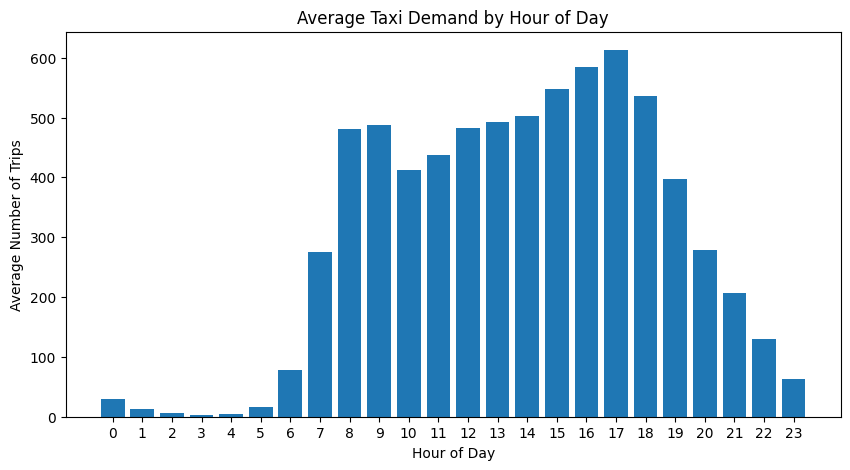

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(hourly_demand_avg.index, hourly_demand_avg.values)

plt.title("Average Taxi Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Number of Trips")
plt.xticks(range(24))

plt.show()

In [13]:
taxi_data_processed["is_weekend"] = (
    taxi_data_processed["Pickup Hour"].dt.dayofweek >= 5
)

hourly_weekend = (
    taxi_data_processed.groupby(["date", "hour", "is_weekend"])
    .size()
    .reset_index(name="trips")
)

hourly_weekend_avg = (
    hourly_weekend
    .groupby(["hour", "is_weekend"])["trips"]
    .mean()
    .unstack()
)

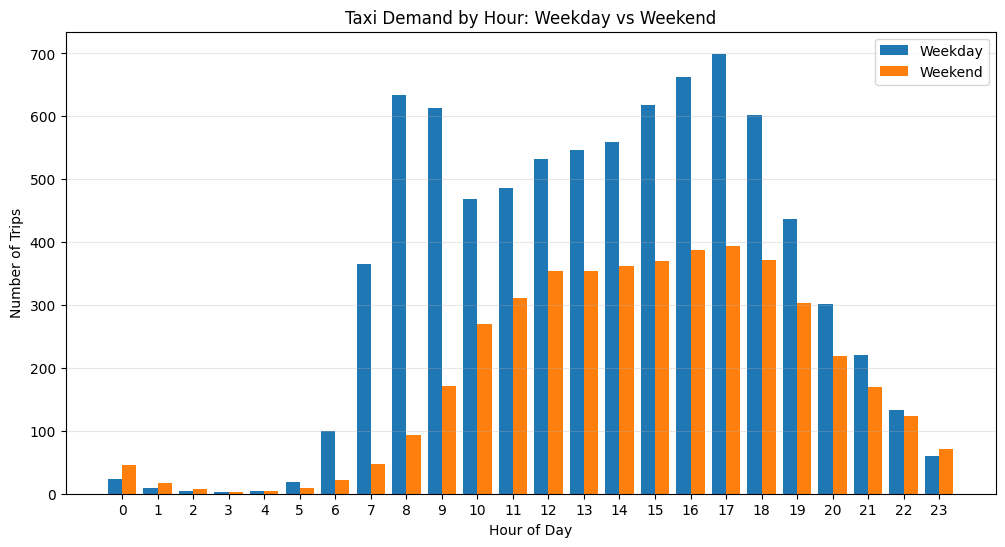

In [17]:
hours = hourly_weekend_avg.index

x = np.arange(len(hours))
width = 0.4

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    hourly_weekend_avg[False],
    width,
    label="Weekday"
)

plt.bar(
    x + width/2,
    hourly_weekend_avg[True],
    width,
    label="Weekend"
)

plt.xticks(x, hours)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Taxi Demand by Hour: Weekday vs Weekend")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

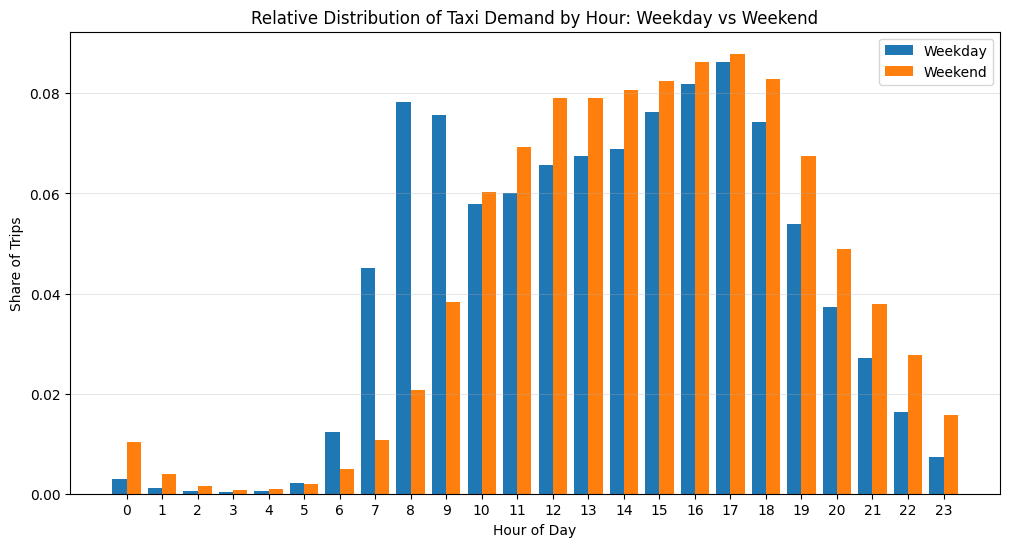

In [21]:
hourly_share = hourly_weekend_avg.div(
    hourly_weekend_avg.sum(axis=0),
    axis=1
)

x = np.arange(len(hours))
width = 0.4

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    hourly_share[False],
    width,
    label="Weekday"
)

plt.bar(
    x + width/2,
    hourly_share[True],
    width,
    label="Weekend"
)

plt.xticks(x, hours)

plt.xlabel("Hour of Day")
plt.ylabel("Share of Trips")
plt.title("Relative Distribution of Taxi Demand by Hour: Weekday vs Weekend")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

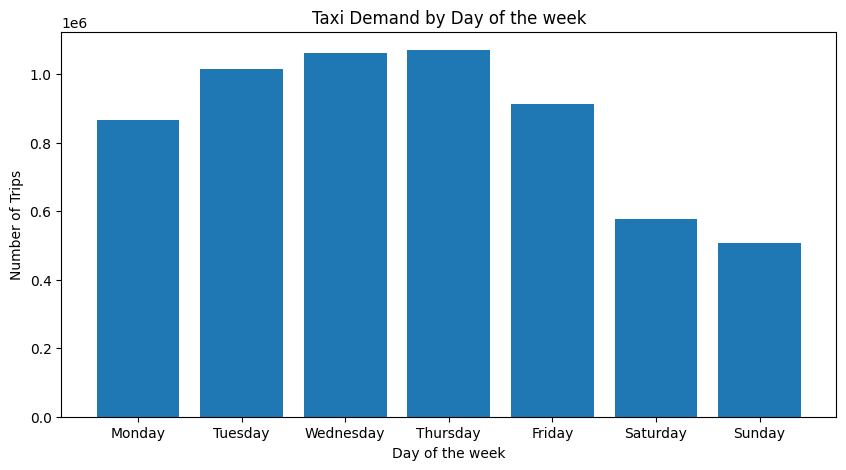

In [18]:
plt.figure(figsize=(10, 5))
plt.bar(weekly_demand.index, weekly_demand.values)

plt.title("Taxi Demand by Day of the week")
plt.xlabel("Day of the week")
plt.ylabel("Number of Trips")

plt.show()

In [26]:
taxi_data_processed["Trip Miles"].describe()

count    6.012349e+06
mean     5.587106e+00
std      7.168033e+00
min      1.000000e-02
25%      9.800000e-01
50%      1.660000e+00
75%      1.064000e+01
max      4.930300e+02
Name: Trip Miles, dtype: float64

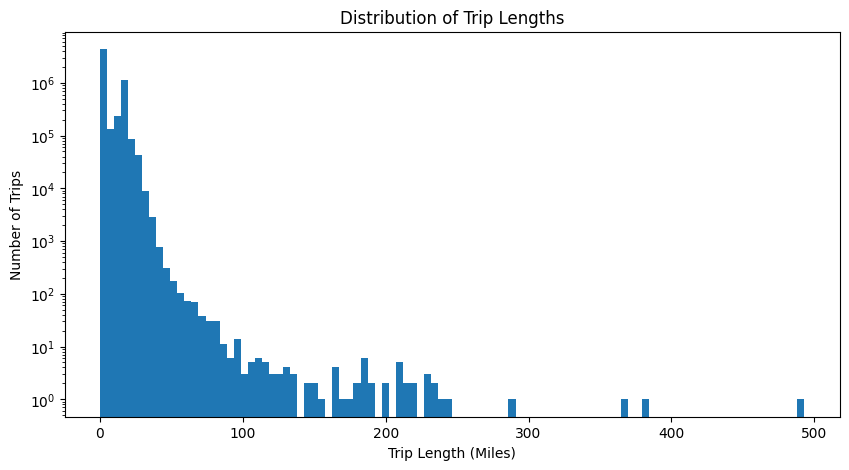

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(
    taxi_data_processed["Trip Miles"],
    bins=100
)
plt.xlabel("Trip Length (Miles)")
plt.ylabel("Number of Trips (log)")
plt.title("Distribution of Trip Lengths")
plt.yscale("log")
plt.show()

In [33]:
hourly_trip_length = (
    taxi_data_processed
    .groupby(
        taxi_data_processed["hour"])["Trip Miles"]
    .mean()
)

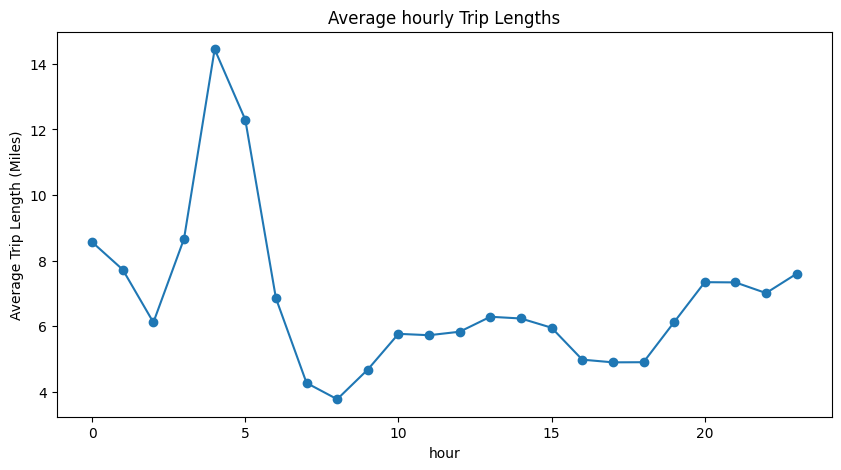

In [44]:
plt.figure(figsize=(10,5))
plt.plot(hourly_trip_length, marker = "o")
plt.xlabel("hour")
plt.ylabel("Average Trip Length (Miles)")
plt.title("Average hourly Trip Lengths")
plt.show()

In [ ]:
## fortfahren mit trip length analysis, price analysis etc

## spatial patterns